# Lab Exercise 3 : Simple Linear Regression
**Dataset : Student Survey - CIA % and Attendance % vs GPA**

## Part A : Data Collection and Preprocessing

### Step 1 : Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Step 2 : Load Dataset

In [2]:
df = pd.read_csv('student_survey.csv')
df.columns = [c.strip() for c in df.columns]

### Step 3 : Display First 5 Rows

In [3]:
df.head()

,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,2026-06-22 08:49:31.362,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,2026-06-22 08:49:50.520,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,2026-06-22 08:50:44.521,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,2026-06-22 08:51:00.666,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,2026-06-22 08:51:42.357,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


### Step 4 : Check Dataset Dimensions

In [4]:
print("Shape:", df.shape)

Shape: (54, 15)


The dataset has 54 rows and 15 columns.

### Step 5 : Check for Missing Values

In [5]:
print(df.isnull().sum())

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your package expectations (LPA)

### Step 6 : Select Relevant Columns and Convert to Numeric

In [6]:
cia_col = 'your CIA % of last semester'
gpa_col = 'your GPA of last semester'
att_col = 'Your maximum attendance % till last semester'

df[cia_col] = pd.to_numeric(df[cia_col], errors='coerce')
df[gpa_col] = pd.to_numeric(df[gpa_col], errors='coerce')
df[att_col] = pd.to_numeric(df[att_col], errors='coerce')

Some entries in the attendance column had text like "Option 1" instead of a number. Using errors='coerce' converts those to NaN so they can be removed.

### Step 7 : Remove Null Values and Invalid Entries

In [7]:
df = df.dropna(subset=[cia_col, gpa_col, att_col])

df = df[(df[gpa_col] >= 0) & (df[gpa_col] <= 10)]
df = df[(df[cia_col] >= 0) & (df[cia_col] <= 100)]
df = df[(df[att_col] >= 0) & (df[att_col] <= 100)]

print("Shape after cleaning:", df.shape)

Shape after cleaning: (45, 15)


Some students entered GPA as 90 which is not valid since our grading is out of 10. Similarly some CIA values were entered as decimals like 0.7 instead of 70. These outliers were filtered out.

### Step 8 : Remove Duplicate Records

In [8]:
df = df.drop_duplicates()
print("Final shape:", df.shape)

Final shape: (45, 15)


### Step 9 : Statistical Summary

In [9]:
df[[cia_col, gpa_col, att_col]].describe()

,your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester
count,45.000000,45.000000,45.000000
mean,57.756247,3.748889,78.969300
std,31.043371,1.174467,34.126669
min,0.630000,2.900000,0.870000
25%,64.670000,3.400000,87.000000
50%,70.000000,3.500000,92.000000
75%,78.000000,3.700000,97.000000
max,89.000000,10.000000,100.000000


The average CIA % is around 57.75 and average GPA is 3.75. Attendance has a wide range, most students are above 87% but some are very low.

### Step 10 : Select Input and Output Variables

In [10]:
X_cia = df[cia_col].values
X_att = df[att_col].values
y = df[gpa_col].values

print("X Values (CIA %):", X_cia)
print("\nX Values (Attendance %):", X_att)
print("\nY Values (GPA):", y)

X Values (CIA %): [70.     68.      0.7     3.45   70.     83.     70.      0.7    70.
 64.67   70.     89.      0.7111 66.     80.     78.      0.7    67.
 80.     80.     78.     60.     85.     70.      0.77   80.     75.
 71.     70.32   71.     70.     70.     70.      0.8    70.      0.75
 77.     72.      4.     71.5    78.     76.     79.33   86.      0.63  ]

X Values (Attendance %): [ 92.      85.       0.87    90.      89.      98.      97.       0.99
  97.      95.      90.      89.       0.9425  91.      93.      95.
   0.986   92.08    95.      95.     100.      86.      99.      85.
   0.97    96.      94.      90.      92.83    95.      87.      92.
  98.03     0.98    89.       0.9     97.99    88.     100.      98.
  99.34    98.71   100.      86.      92.    ]

Y Values (GPA): [ 3.2   3.4   3.5  10.    3.4   3.89  3.3   3.5   3.48  3.4   2.9   3.67
  3.37  2.9   3.6   3.75  3.6   3.46  3.64  3.7   3.4   3.4   3.6   3.4
  3.6   3.86  3.6   3.4   3.29  3.51  3.5   3.6 

## Part B : Simple Linear Regression using Scikit-learn

### Experiment 1 : CIA % -> GPA

#### Scatter Plot

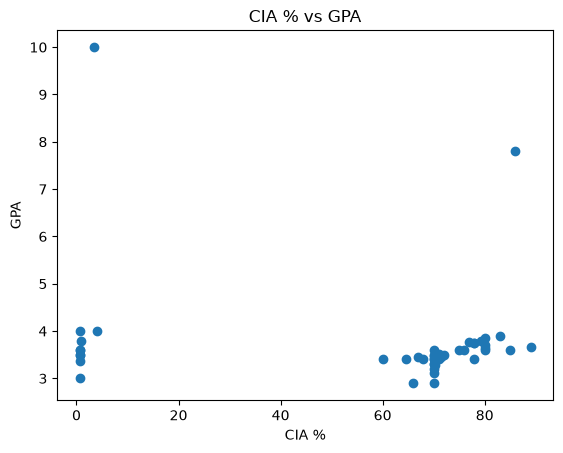

In [11]:
plt.scatter(X_cia, y)
plt.xlabel("CIA %")
plt.ylabel("GPA")
plt.title("CIA % vs GPA")
plt.show()

#### Train Test Split

In [12]:
X_cia_2d = X_cia.reshape(-1, 1)

X_cia_train, X_cia_test, y_cia_train, y_cia_test = train_test_split(
    X_cia_2d, y, test_size=0.2, random_state=2
)

print("Shape of X_cia_train:", X_cia_train.shape)

Shape of X_cia_train: (36, 1)


#### Train Model

In [13]:
lr_cia = LinearRegression()
lr_cia.fit(X_cia_train, y_cia_train)

print("Slope (m):", lr_cia.coef_[0])
print("Intercept (b):", lr_cia.intercept_)

Slope (m): -0.010377416335029432
Intercept (b): 4.301737883624094


#### Predict Values

In [14]:
y_cia_pred = lr_cia.predict(X_cia_test)

#### Compare Actual vs Predicted

In [15]:
comparison_cia_sklearn = pd.DataFrame({
    'Actual': y_cia_test,
    'Predicted': y_cia_pred
})

print(comparison_cia_sklearn.head())

   Actual  Predicted
0    3.60   3.513054
1    3.46   3.606451
2    7.80   3.409280
3    3.60   3.471545
4    4.00   4.295200


#### Predict for a Sample Input

In [16]:
sample_pred = lr_cia.predict([[75]])

print("Predicted GPA for CIA % = 75:")
print(sample_pred)

Predicted GPA for CIA % = 75:
[3.52343166]


#### Plot Regression Line

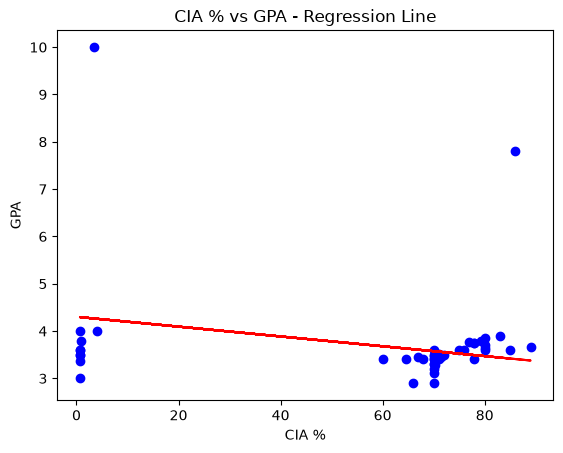

In [17]:
plt.scatter(X_cia, y, color='blue')
plt.plot(X_cia_train, lr_cia.predict(X_cia_train), color='red')
plt.xlabel("CIA %")
plt.ylabel("GPA")
plt.title("CIA % vs GPA - Regression Line")
plt.show()

#### Model Evaluation

In [18]:
print("MAE :", mean_absolute_error(y_cia_test, y_cia_pred))
print("MSE :", mean_squared_error(y_cia_test, y_cia_pred))
print("R2 Score :", r2_score(y_cia_test, y_cia_pred))

MAE : 0.7910243527893814
MSE : 2.3248041217106836
R2 Score : -0.19535702089688312


The R2 score is negative which means the model is not doing a good job of predicting GPA from CIA %. A negative R2 means the model is worse than just predicting the average GPA for everyone. The data points are very scattered and do not follow a clear linear pattern.

### Experiment 2 : Attendance % -> GPA

#### Scatter Plot

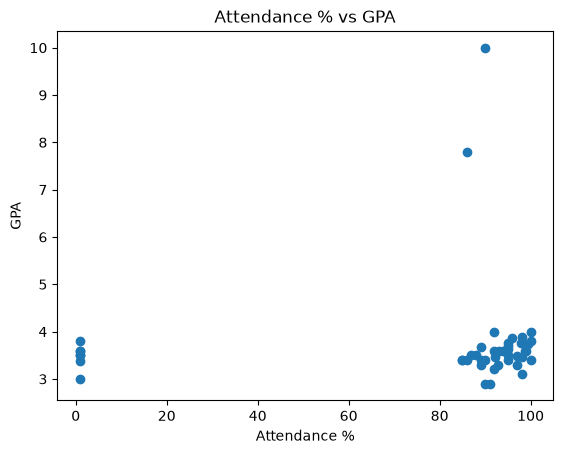

In [19]:
plt.scatter(X_att, y)
plt.xlabel("Attendance %")
plt.ylabel("GPA")
plt.title("Attendance % vs GPA")
plt.show()

#### Train Test Split

In [20]:
X_att_2d = X_att.reshape(-1, 1)

X_att_train, X_att_test, y_att_train, y_att_test = train_test_split(
    X_att_2d, y, test_size=0.2, random_state=2
)

print("Shape of X_att_train:", X_att_train.shape)

Shape of X_att_train: (36, 1)


#### Train Model

In [21]:
lr_att = LinearRegression()
lr_att.fit(X_att_train, y_att_train)

print("Slope (m):", lr_att.coef_[0])
print("Intercept (b):", lr_att.intercept_)

Slope (m): 0.002357596962460972
Intercept (b): 3.5174541252958607


#### Predict Values

In [22]:
y_att_pred = lr_att.predict(X_att_test)

#### Compare Actual vs Predicted

In [23]:
comparison_att_sklearn = pd.DataFrame({
    'Actual': y_att_test,
    'Predicted': y_att_pred
})

print(comparison_att_sklearn.head())

   Actual  Predicted
0    3.60   3.750173
1    3.46   3.734542
2    7.80   3.720207
3    3.60   3.736711
4    4.00   3.734353


#### Predict for a Sample Input

In [24]:
sample_pred_att = lr_att.predict([[90]])

print("Predicted GPA for Attendance % = 90:")
print(sample_pred_att)

Predicted GPA for Attendance % = 90:
[3.72963785]


#### Plot Regression Line

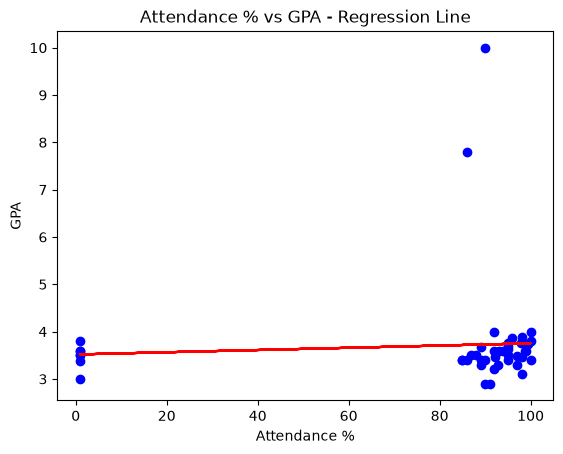

In [25]:
plt.scatter(X_att, y, color='blue')
plt.plot(X_att_train, lr_att.predict(X_att_train), color='red')
plt.xlabel("Attendance %")
plt.ylabel("GPA")
plt.title("Attendance % vs GPA - Regression Line")
plt.show()

#### Model Evaluation

In [26]:
print("MAE :", mean_absolute_error(y_att_test, y_att_pred))
print("MSE :", mean_squared_error(y_att_test, y_att_pred))
print("R2 Score :", r2_score(y_att_test, y_att_pred))

MAE : 0.7393683110932577
MSE : 1.9872889579542514
R2 Score : -0.021815036482928596


Attendance also does not predict GPA well. The R2 score is very close to 0 which means there is almost no linear relationship between attendance and GPA in our class data. The slope is positive but very small.

## Part C : Manual Computation using OLS

OLS formulas:

$$m = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$$

$$b = \bar{y} - m \cdot \bar{x}$$

### Create Custom Linear Regression Class

In [27]:
class LR:

    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):
        num = 0
        den = 0
        for i in range(X_train.shape[0]):
            num = num + (X_train[i] - X_train.mean()) * (y_train[i] - y_train.mean())
            den = den + (X_train[i] - X_train.mean()) * (X_train[i] - X_train.mean())
        self.m = num / den
        self.b = y_train.mean() - (self.m * X_train.mean())
        print("Slope (m) =", self.m)
        print("Intercept (b) =", self.b)

    def predict(self, X_test):
        print("Input Value:", X_test)
        return self.m * X_test + self.b

### OLS Experiment 1 : CIA % -> GPA

In [28]:
lr_cia_ols = LR()
lr_cia_ols.fit(X_cia, y)

Slope (m) = -0.006003566060537298
Intercept (b) = 4.0956323311609095


In [29]:
pred_ols_cia = lr_cia_ols.predict(X_cia_test[0][0])

print("\nPredicted GPA:", pred_ols_cia)

Input Value: 76.0

Predicted GPA: 3.6393613105600746


In [30]:
print("Regression Equation:")
print(f"GPA = {lr_cia_ols.m:.4f} * CIA% + ({lr_cia_ols.b:.4f})")

Regression Equation:
GPA = -0.0060 * CIA% + (4.0956)


### OLS Experiment 2 : Attendance % -> GPA

In [31]:
lr_att_ols = LR()
lr_att_ols.fit(X_att, y)

Slope (m) = 0.0026436735952343826
Intercept (b) = 3.5401198356447465


In [32]:
pred_ols_att = lr_att_ols.predict(X_att_test[0][0])

print("\nPredicted GPA:", pred_ols_att)

Input Value: 98.71

Predicted GPA: 3.8010768562303325


In [33]:
print("Regression Equation:")
print(f"GPA = {lr_att_ols.m:.4f} * Attendance% + ({lr_att_ols.b:.4f})")

Regression Equation:
GPA = 0.0026 * Attendance% + (3.5401)


## Comparison : Scikit-learn vs OLS

### Experiment 1 : CIA % -> GPA

In [34]:
print("CIA % -> GPA")
print("Sklearn  Slope:", round(lr_cia.coef_[0], 4), "  Intercept:", round(lr_cia.intercept_, 4))
print("OLS      Slope:", round(lr_cia_ols.m, 4),    "  Intercept:", round(lr_cia_ols.b, 4))

CIA % -> GPA
Sklearn  Slope: -0.0104   Intercept: 4.3017
OLS      Slope: -0.006   Intercept: 4.0956


In [35]:
ols_cia_preds = lr_cia_ols.m * X_cia_test.flatten() + lr_cia_ols.b

comparison_cia = pd.DataFrame({
    'X (CIA %)': X_cia_test.flatten(),
    'Actual GPA': y_cia_test,
    'Sklearn Predicted': y_cia_pred,
    'OLS Predicted': ols_cia_preds,
    'Difference': abs(y_cia_pred - ols_cia_preds)
})

print(comparison_cia.head(10).to_string(index=False))

 X (CIA %)  Actual GPA  Sklearn Predicted  OLS Predicted  Difference
   76.0000        3.60           3.513054       3.639361    0.126307
   67.0000        3.46           3.606451       3.693393    0.086942
   86.0000        7.80           3.409280       3.579326    0.170046
   80.0000        3.60           3.471545       3.615347    0.143802
    0.6300        4.00           4.295200       4.091850    0.203350
   71.0000        3.51           3.564941       3.669379    0.104438
    0.7111        3.37           4.294359       4.091363    0.202995
   66.0000        2.90           3.616828       3.699397    0.082569
   70.0000        3.20           3.575319       3.675383    0.100064


### Experiment 2 : Attendance % -> GPA

In [36]:
print("Attendance % -> GPA")
print("Sklearn  Slope:", round(lr_att.coef_[0], 4), "  Intercept:", round(lr_att.intercept_, 4))
print("OLS      Slope:", round(lr_att_ols.m, 4),    "  Intercept:", round(lr_att_ols.b, 4))

Attendance % -> GPA
Sklearn  Slope: 0.0024   Intercept: 3.5175
OLS      Slope: 0.0026   Intercept: 3.5401


In [37]:
ols_att_preds = lr_att_ols.m * X_att_test.flatten() + lr_att_ols.b

comparison_att = pd.DataFrame({
    'X (Att %)': X_att_test.flatten(),
    'Actual GPA': y_att_test,
    'Sklearn Predicted': y_att_pred,
    'OLS Predicted': ols_att_preds,
    'Difference': abs(y_att_pred - ols_att_preds)
})

print(comparison_att.head(10).to_string(index=False))

 X (Att %)  Actual GPA  Sklearn Predicted  OLS Predicted  Difference
   98.7100        3.60           3.750173       3.801077    0.050904
   92.0800        3.46           3.734542       3.783549    0.049008
   86.0000        7.80           3.720207       3.767476    0.047268
   93.0000        3.60           3.736711       3.785981    0.049271
   92.0000        4.00           3.734353       3.783338    0.048985
   95.0000        3.51           3.741426       3.791269    0.049843
    0.9425        3.37           3.519676       3.542611    0.022935
   91.0000        2.90           3.731995       3.780694    0.048699
   92.0000        3.20           3.734353       3.783338    0.048985


### Observations

The slope and intercept from Scikit-learn and OLS are slightly different because Scikit-learn was trained only on the training set (80% of data) while the OLS calculation was done on the full dataset. If both were trained on the same data the values would be exactly the same since Scikit-learn LinearRegression also uses OLS internally.

The difference between predictions from both methods is very small, which shows both approaches give consistent results. Neither model predicted GPA very accurately from CIA % or Attendance % alone, which tells us GPA depends on many other factors.

## Parameter Saving using Pickle

### Save Parameters

In [38]:
parameters = {
    'exp1_cia_gpa': {
        'slope': lr_cia.coef_[0],
        'intercept': lr_cia.intercept_
    },
    'exp2_att_gpa': {
        'slope': lr_att.coef_[0],
        'intercept': lr_att.intercept_
    }
}

with open('linear_regression_weights.pkl', 'wb') as f:
    pickle.dump(parameters, f)

print("Parameters saved successfully")

Parameters saved successfully


### Load Parameters

In [39]:
with open('linear_regression_weights.pkl', 'rb') as f:
    loaded_params = pickle.load(f)

print("Loaded parameters:")
print(loaded_params)

Loaded parameters:
{'exp1_cia_gpa': {'slope': np.float64(-0.010377416335029432), 'intercept': np.float64(4.301737883624094)}, 'exp2_att_gpa': {'slope': np.float64(0.002357596962460972), 'intercept': np.float64(3.5174541252958607)}}


### Use Loaded Parameters for Prediction

In [40]:
m = loaded_params['exp1_cia_gpa']['slope']
b = loaded_params['exp1_cia_gpa']['intercept']

cia_input = 75
predicted_gpa = m * cia_input + b

print(f"Predicted GPA for CIA % = {cia_input}: {predicted_gpa:.4f}")

Predicted GPA for CIA % = 75: 3.5234


## Final Observations

Both experiments showed that CIA % and Attendance % alone are not strong predictors of GPA based on our class survey data. The R2 scores were very low or negative which means the linear model was not able to find a clear pattern.

One reason for this could be that the survey had some inconsistent entries that had to be removed during cleaning. With only 45 samples remaining the dataset is also quite small for regression.

Between the two experiments, attendance had a slightly better R2 score compared to CIA %. This may suggest attendance has a marginally better relationship with GPA but still not a strong one.

The Scikit-learn and manual OLS methods gave nearly the same results, which confirms that Scikit-learn uses OLS internally. Saving parameters with Pickle allows us to reuse the trained model without retraining.